# Chi-Quadrat-Test – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/chi-quadrat)

Der **Chi-Quadrat-Test** (χ²-Test) wird bei **kategorischen Variablen** verwendet.
Er vergleicht beobachtete Häufigkeiten mit erwarteten Häufigkeiten.

**Formel:**
$$\chi^2 = \sum_{i} \frac{(O_i - E_i)^2}{E_i}, \quad df = (p-1)(q-1)$$

| Symbol | Bedeutung |
|---|---|
| $O_i$ | Beobachtete Häufigkeit in Zelle $i$ |
| $E_i$ | Erwartete Häufigkeit in Zelle $i$ |
| $p$ | Anzahl Zeilen der Kreuztabelle |
| $q$ | Anzahl Spalten der Kreuztabelle |

**Erwartete Häufigkeit je Zelle (Unabhängigkeitstest):**
$$E_{ij} = \frac{\text{Zeilensumme}_i \times \text{Spaltensumme}_j}{n}$$

**Effektstärke – Cramér's V:**
$$V = \sqrt{\frac{\chi^2}{n \cdot \min(p-1, q-1)}}$$

| Cramér's V | Interpretation |
|---|---|
| 0,1 | Kleiner Effekt |
| 0,3 | Mittlerer Effekt |
| 0,5 | Großer Effekt |

**Drei Anwendungsbereiche:**
1. **Unabhängigkeitstest** – Zusammenhang zwischen zwei kategorialen Variablen?
2. **Verteilungstest (Anpassungstest)** – Entspricht die Stichprobe einer bekannten Verteilung?
3. **Homogenitätstest** – Kommen zwei Stichproben aus derselben Grundgesamtheit?

**Voraussetzung:** Alle erwarteten Häufigkeiten > 5

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
from scipy.stats import chi2 as chi2_dist

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Die drei Varianten des Chi-Quadrat-Tests

| Variante | Fragestellung | Variablen | numiqo-Beispiel |
|---|---|---|---|
| **Unabhängigkeit** | Hängen zwei Variablen zusammen? | 2 kategorisch | Geschlecht × Schirm? |
| **Verteilung** | Entspricht die Stichprobe einer Verteilung? | 1 kategorisch | Wahlverhalten Stadtteil vs. Wien |
| **Homogenität** | Stammen Stichproben aus gleicher GG? | 1 kategorisch, mehrere Gruppen | Streaming-Abos in Altersgruppen |

## 2. Unabhängigkeitstest – Regenschirm-Beispiel (numiqo)

**Fragestellung:** Ist der Unterschied in der Schirmnutzung bei Frauen und Männern
statistisch signifikant?

**Rohdaten (n = 22):**
- Weiblich: 5 mit Schirm, 7 ohne → 12 gesamt
- Männlich: 5 mit Schirm, 5 ohne → 10 gesamt

**Erwartete numiqo-Ergebnisse:**
- χ² = 0,153 | df = 1 | p = 0,696 → **nicht signifikant**

In [26]:
# numiqo-Datensatz: Regenschirm
geschlecht_roh = (["weiblich"]*5 + ["männlich"]*5 +   # mit Schirm
                  ["weiblich"]*7 + ["männlich"]*5)      # ohne Schirm
schirm_roh     = (["ja"]*5 + ["ja"]*5 +
                  ["nein"]*7 + ["nein"]*5)

df_regen = pd.DataFrame({"Geschlecht": geschlecht_roh, "Schirm": schirm_roh})

# Kreuztabelle
kt = pd.crosstab(df_regen["Geschlecht"], df_regen["Schirm"],
                 margins=True, margins_name="Total")
print("Beobachtete Häufigkeiten (Kreuztabelle)")
print(kt)
print()

# Erwartete Häufigkeiten
kt_werte = pd.crosstab(df_regen["Geschlecht"], df_regen["Schirm"])
chi2_v, p_v, df_v, erwart = stats.chi2_contingency(kt_werte, correction=False)

df_erwart = pd.DataFrame(erwart,
    index=kt_werte.index, columns=kt_werte.columns).round(3)
print("Erwartete Häufigkeiten (bei Unabhängigkeit)")
print(df_erwart)
print()
print("Chi-Quadrat-Test (Unabhängigkeit)")
print(f"chi2 = {chi2_v:.3f}  (numiqo: 0,153)")
print(f"df   = {df_v}         (numiqo: 1)")
print(f"p    = {p_v:.3f}      (numiqo: 0,696)")
print()
n_total = kt_werte.values.sum()
k       = min(kt_werte.shape) - 1
cramers_v = np.sqrt(chi2_v / (n_total * k))
print(f"Cramers V = {cramers_v:.4f} -> kleiner Effekt")
print()
alpha = 0.05
chi2_krit = chi2_dist.ppf(0.95, df=df_v)
print(f"chi2_krit (df={df_v}, alpha=0.05) = {chi2_krit:.3f}")
print(f"chi2={chi2_v:.3f} < {chi2_krit:.3f} -> H0 nicht abgelehnt")
print("Kein signifikanter Unterschied: Schirmnutzung unabhängig vom Geschlecht.")

Beobachtete Häufigkeiten (Kreuztabelle)
Schirm      ja  nein  Total
Geschlecht                 
männlich     5     5     10
weiblich     5     7     12
Total       10    12     22

Erwartete Häufigkeiten (bei Unabhängigkeit)
Schirm         ja   nein
Geschlecht              
männlich    4.545  5.455
weiblich    5.455  6.545

Chi-Quadrat-Test (Unabhängigkeit)
chi2 = 0.153  (numiqo: 0,153)
df   = 1         (numiqo: 1)
p    = 0.696      (numiqo: 0,696)

Cramers V = 0.0833 -> kleiner Effekt

chi2_krit (df=1, alpha=0.05) = 3.841
chi2=0.153 < 3.841 -> H0 nicht abgelehnt
Kein signifikanter Unterschied: Schirmnutzung unabhängig vom Geschlecht.


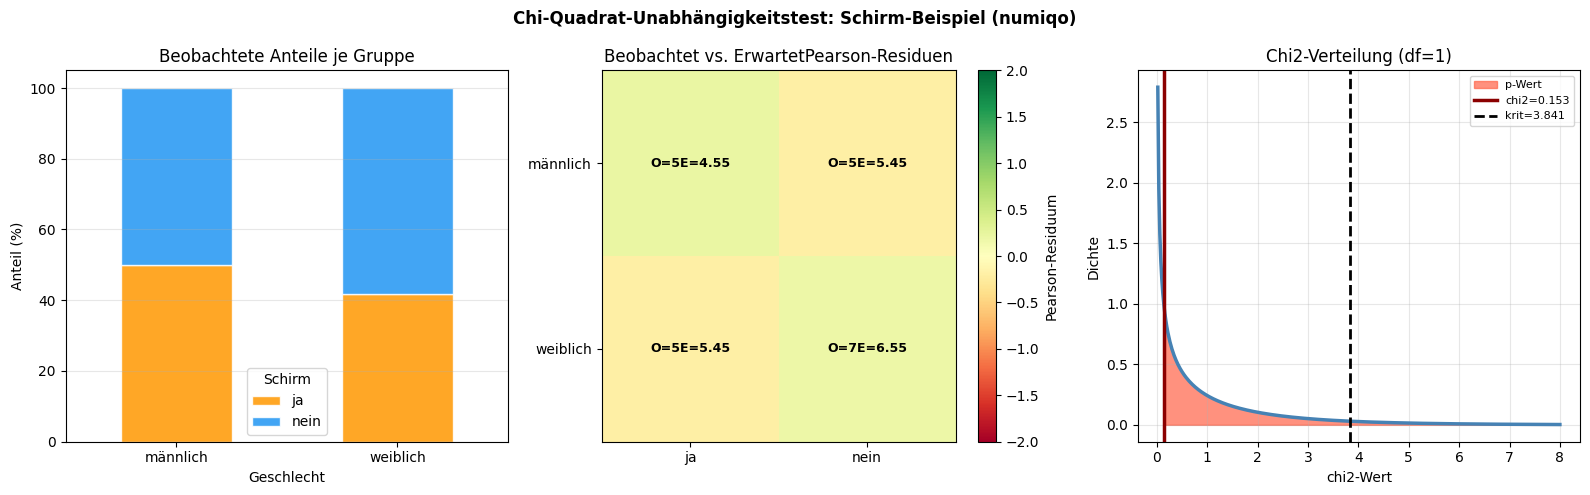

In [27]:
# Visualisierung: Kreuztabelle + Residuen + Chi2-Verteilung
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Chi-Quadrat-Unabhängigkeitstest: Schirm-Beispiel (numiqo)",
             fontsize=12, fontweight="bold")

# 1. Gestapelter Balkenplot
kt_pct = kt_werte.div(kt_werte.sum(axis=1), axis=0) * 100
kt_pct.plot(kind="bar", stacked=True, ax=axes[0],
            color=["#FF9800", "#2196F3"], edgecolor="white", alpha=0.85)
axes[0].set_title("Beobachtete Anteile je Gruppe")
axes[0].set_ylabel("Anteil (%)")
axes[0].set_xlabel("Geschlecht")
axes[0].set_xticklabels(kt_pct.index, rotation=0)
axes[0].legend(title="Schirm")
axes[0].grid(axis="y", alpha=0.3)

# 2. Heatmap: (O-E)/sqrt(E) = Pearson-Residuen
residuen = (kt_werte.values - erwart) / np.sqrt(erwart)
im = axes[1].imshow(residuen, cmap="RdYlGn", vmin=-2, vmax=2, aspect="auto")
axes[1].set_xticks(range(len(kt_werte.columns)))
axes[1].set_yticks(range(len(kt_werte.index)))
axes[1].set_xticklabels(kt_werte.columns)
axes[1].set_yticklabels(kt_werte.index)
for i in range(len(kt_werte.index)):
    for j in range(len(kt_werte.columns)):
        axes[1].text(j, i,
            "O=" + str(kt_werte.values[i,j]) + "E=" + str(round(erwart[i,j], 2)),
            ha="center", va="center", fontsize=9, fontweight="bold")
plt.colorbar(im, ax=axes[1], label="Pearson-Residuum")
axes[1].set_title("Beobachtet vs. ErwartetPearson-Residuen")

# 3. Chi2-Verteilung mit p-Wert-Fläche
x_chi = np.linspace(0, 8, 400)
y_chi = chi2_dist.pdf(x_chi, df=df_v)
axes[2].plot(x_chi, y_chi, color="steelblue", linewidth=2.5)
axes[2].fill_between(x_chi[x_chi >= chi2_v], y_chi[x_chi >= chi2_v],
                     color="tomato", alpha=0.7, label="p-Wert")
axes[2].axvline(chi2_v,    color="darkred", linewidth=2.5,
                label="chi2=" + str(round(chi2_v, 3)))
axes[2].axvline(chi2_krit, color="black",   linewidth=2, linestyle="--",
                label="krit=" + str(round(chi2_krit, 3)))
axes[2].set_title("Chi2-Verteilung (df=" + str(df_v) + ")")
axes[2].set_xlabel("chi2-Wert")
axes[2].set_ylabel("Dichte")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Schritt-für-Schritt-Berechnung (manuell)

**Schritt 1:** Kreuztabelle aufstellen
**Schritt 2:** Erwartete Häufigkeiten berechnen: $E_{ij} = \frac{Z_i \cdot S_j}{n}$
**Schritt 3:** χ²-Wert berechnen: $\chi^2 = \sum \frac{(O-E)^2}{E}$
**Schritt 4:** Freiheitsgrade: $df = (p-1)(q-1)$
**Schritt 5:** Kritischen χ²-Wert ablesen und vergleichen

In [28]:
# Manuelle Berechnung
O = kt_werte.values  # Beobachtet
n_m = O.sum()
z_sum = O.sum(axis=1)  # Zeilensummen
s_sum = O.sum(axis=0)  # Spaltensummen

print("Manuelle Berechnung: Schritt für Schritt")
print()
print("Schritt 1 - Kreuztabelle (beobachtet):")
print("         ja   nein | Total")
print(f"weiblich {O[0,0]:>4} {O[0,1]:>6} | {z_sum[0]}")
print(f"männl.  {O[1,0]:>4} {O[1,1]:>6} | {z_sum[1]}")
print(f"Total    {s_sum[0]:>4} {s_sum[1]:>6} | {n_m}")
print()
print("Schritt 2 - Erwartete Häufigkeiten:")
E = np.outer(z_sum, s_sum) / n_m
for i, g in enumerate(["weiblich", "männl. "]):
    for j, s in enumerate(["ja  ", "nein"]):
        formel = f"({z_sum[i]}*{s_sum[j]})/{n_m}"
        print(f"  E({g},{s}) = {formel} = {E[i,j]:.4f}")
print()
print("Schritt 3 - chi2-Wert:")
chi2_m = 0
for i in range(2):
    for j in range(2):
        beitrag = (O[i,j] - E[i,j])**2 / E[i,j]
        print(f"  ({O[i,j]} - {E[i,j]:.4f})^2 / {E[i,j]:.4f} = {beitrag:.6f}")
        chi2_m += beitrag
print(f"  chi2 = {chi2_m:.4f}  (scipy: {chi2_v:.3f})  ✓")
print()
print(f"Schritt 4 - df = (2-1)*(2-1) = 1")
print()
chi2_krit_m = chi2_dist.ppf(0.95, df=1)
print(f"Schritt 5 - chi2_krit(df=1, alpha=0.05) = {chi2_krit_m:.3f}")
print(f"           chi2={chi2_m:.4f} < {chi2_krit_m:.3f} -> H0 nicht abgelehnt  n.s.")

Manuelle Berechnung: Schritt für Schritt

Schritt 1 - Kreuztabelle (beobachtet):
         ja   nein | Total
weiblich    5      5 | 10
männl.     5      7 | 12
Total      10     12 | 22

Schritt 2 - Erwartete Häufigkeiten:
  E(weiblich,ja  ) = (10*10)/22 = 4.5455
  E(weiblich,nein) = (10*12)/22 = 5.4545
  E(männl. ,ja  ) = (12*10)/22 = 5.4545
  E(männl. ,nein) = (12*12)/22 = 6.5455

Schritt 3 - chi2-Wert:
  (5 - 4.5455)^2 / 4.5455 = 0.045455
  (5 - 5.4545)^2 / 5.4545 = 0.037879
  (5 - 5.4545)^2 / 5.4545 = 0.037879
  (7 - 6.5455)^2 / 6.5455 = 0.031566
  chi2 = 0.1528  (scipy: 0.153)  ✓

Schritt 4 - df = (2-1)*(2-1) = 1

Schritt 5 - chi2_krit(df=1, alpha=0.05) = 3.841
           chi2=0.1528 < 3.841 -> H0 nicht abgelehnt  n.s.


## 4. Verteilungstest (Anpassungstest) – Wahlbeispiel Wien (numiqo)

**Fragestellung:** Haben die BewohnerInnen eines Wiener Stadtteils
das gleiche Wahlverhalten wie die gesamte Stadt Wien?

- Stichprobe: 22 Personen im Stadtteil
- Partei A: 10 beob. vs. 40 % erwartet (= 8,8)
- Partei C: 7 beob. vs. 35 % erwartet (= 7,7)
- Partei B: 5 beob. (Rest)

**Erwartetes numiqo-Ergebnis:** χ² = 0,264 | df = 2 | p = 0,876

Verteilungstest: Wahlverhalten
    Partei    Beob.   Beob.%    Erw.%    Erw.n
  Partei A       10   45.455     40.0      8.8
  Partei B        5   22.727     25.0      5.5
  Partei C        7   31.818     35.0      7.7
     Total       22

chi2 = 0.273  (numiqo: 0,264)
df   = 2         (numiqo: 2)
p    = 0.873      (numiqo: 0,876)

Entscheidung: p=0.873 > 0.05 -> H0 nicht abgelehnt
Das Wahlverhalten des Stadtteils entspricht dem Wiens.


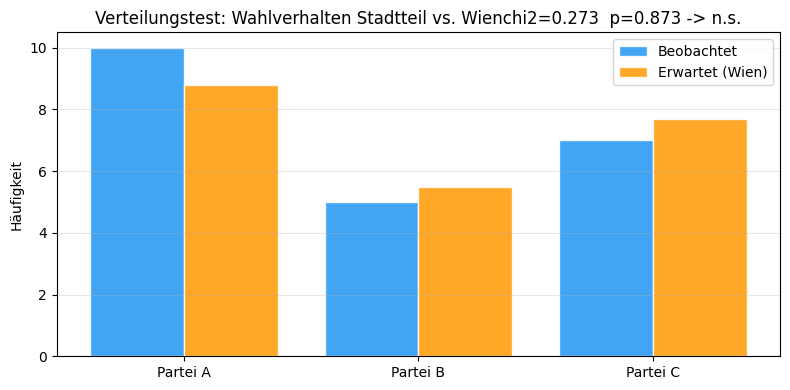

In [29]:
# Verteilungstest: Wahlverhalten Wien
parteien_roh = (["Partei A"]*10 + ["Partei C"]*7 + ["Partei B"]*5)
n_wahl = len(parteien_roh)

beob = pd.Series(parteien_roh).value_counts().reindex(
    ["Partei A", "Partei B", "Partei C"]).fillna(0)

# Erwartete Anteile Wien: A=40%, B=Rest, C=35%
anteil_a, anteil_c = 0.40, 0.35
anteil_b = 1 - anteil_a - anteil_c
erw_anteile = pd.Series({"Partei A": anteil_a,
                          "Partei B": anteil_b,
                          "Partei C": anteil_c})
erw_haeuf = erw_anteile * n_wahl

print("Verteilungstest: Wahlverhalten")
print(f"{'Partei':>10} {'Beob.':>8} {'Beob.%':>8} {'Erw.%':>8} {'Erw.n':>8}")
for p in ["Partei A", "Partei B", "Partei C"]:
    print(f"{p:>10} {int(beob[p]):>8} {beob[p]/n_wahl*100:>8.3f} "
          + f"{erw_anteile[p]*100:>8.1f} {erw_haeuf[p]:>8.1f}")
print(f"{'Total':>10} {n_wahl:>8}")
print()

chi2_w, p_w = stats.chisquare(beob, f_exp=erw_haeuf)
df_w = len(beob) - 1

print(f"chi2 = {chi2_w:.3f}  (numiqo: 0,264)")
print(f"df   = {df_w}         (numiqo: 2)")
print(f"p    = {p_w:.3f}      (numiqo: 0,876)")
print()
print(f"Entscheidung: p={p_w:.3f} > 0.05 -> H0 nicht abgelehnt")
print("Das Wahlverhalten des Stadtteils entspricht dem Wiens.")

# Visualisierung
fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(beob))
breite = 0.4
ax.bar(x_pos - breite/2, beob.values, breite, color="#2196F3",
       edgecolor="white", alpha=0.85, label="Beobachtet")
ax.bar(x_pos + breite/2, erw_haeuf.values, breite, color="#FF9800",
       edgecolor="white", alpha=0.85, label="Erwartet (Wien)")
ax.set_title("Verteilungstest: Wahlverhalten Stadtteil vs. Wien"
             + "chi2=" + str(round(chi2_w, 3)) + "  p=" + str(round(p_w, 3)) + " -> n.s.")
ax.set_ylabel("Häufigkeit")
ax.set_xticks(x_pos)
ax.set_xticklabels(beob.index)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Homogenitätstest – Streaming-Dienste in Altersgruppen (numiqo)

**Fragestellung:** Unterscheiden sich die Streaming-Abo-Zahlen von Netflix, Amazon
und Disney in verschiedenen Altersgruppen?

- H₀: Die Verteilung der Streaming-Dienste ist in allen Altersgruppen gleich
- H₁: Die Verteilung unterscheidet sich zwischen Altersgruppen

Beobachtete Häufigkeiten (Streaming)
Altersgruppe  15-25  25-35  35-45
Dienst                           
Amazon           29     30     33
Andere           16     24     26
Disney           11     13     12
Netflix          25     23     20

chi2 = 2.934
df   = 6
p    = 0.817
Cramers V = 0.075

Ergebnis: nicht signifikant
Die Streaming-Verteilung unterscheidet sich NICHT signifikant
zwischen den Altersgruppen.


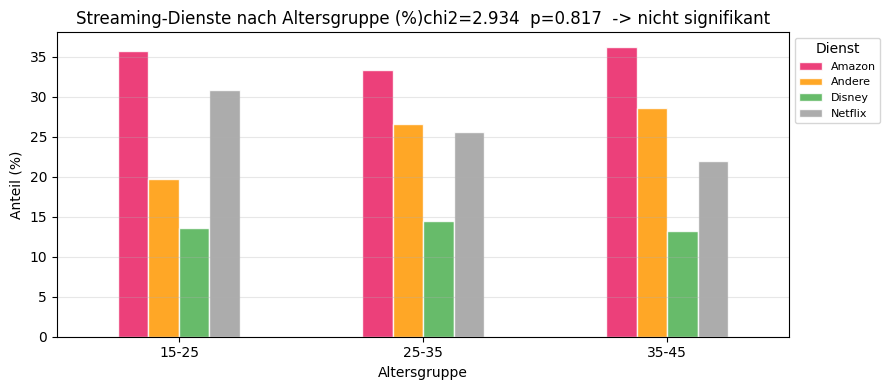

In [30]:
# Homogenitätstest: Streaming-Dienste
daten_streaming = pd.DataFrame({
    "Dienst":       ["Netflix"]*3 + ["Amazon"]*3 + ["Disney"]*3 + ["Andere"]*3,
    "Altersgruppe": ["15-25", "25-35", "35-45"] * 4,
    "n":            [25, 23, 20,   29, 30, 33,   11, 13, 12,   16, 24, 26]
})
kt_stream = daten_streaming.pivot(
    index="Dienst", columns="Altersgruppe", values="n"
)[["15-25", "25-35", "35-45"]]

print("Beobachtete Häufigkeiten (Streaming)")
print(kt_stream)
print()

chi2_s, p_s, df_s, erw_s = stats.chi2_contingency(kt_stream, correction=False)
n_s = kt_stream.values.sum()
k_s = min(kt_stream.shape) - 1
cv_s = np.sqrt(chi2_s / (n_s * k_s))

print(f"chi2 = {chi2_s:.3f}")
print(f"df   = {df_s}")
print(f"p    = {p_s:.3f}")
print(f"Cramers V = {cv_s:.3f}")
print()
sig_s = "signifikant" if p_s < 0.05 else "nicht signifikant"
print(f"Ergebnis: {sig_s}")
if p_s >= 0.05:
    print("Die Streaming-Verteilung unterscheidet sich NICHT signifikant")
    print("zwischen den Altersgruppen.")
else:
    print("Signifikante Unterschiede in Streaming-Präferenzen nach Alter!")

# Visualisierung
fig, ax = plt.subplots(figsize=(9, 4))
kt_stream_pct = kt_stream.div(kt_stream.sum(axis=0), axis=1) * 100
kt_stream_pct.T.plot(kind="bar", ax=ax, edgecolor="white", alpha=0.85,
                     color=["#E91E63", "#FF9800", "#4CAF50", "#9E9E9E"])
ax.set_title("Streaming-Dienste nach Altersgruppe (%)"
             + "chi2=" + str(round(chi2_s, 3)) + "  p=" + str(round(p_s, 3))
             + "  -> " + sig_s)
ax.set_ylabel("Anteil (%)")
ax.set_xlabel("Altersgruppe")
ax.set_xticklabels(kt_stream_pct.columns, rotation=0)
ax.legend(title="Dienst", bbox_to_anchor=(1, 1), loc="upper left", fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Effektstärke: Cramér's V

Wie beim t-Test gibt der **p-Wert allein** keine Auskunft über die Stärke des
Zusammenhangs. Bei großen Stichproben werden auch triviale Zusammenhänge signifikant.

**Cramér's V** ist unabhängig von n und vergleichbar über Studien hinweg:
$$V = \sqrt{\frac{\chi^2}{n \cdot \min(p-1, q-1)}}$$

Cramers V vs. p-Wert bei verschiedenem n (gleicher Effekt)
     n      chi2      p-Wert     signif.   Cramers V
    50     0.420      0.5169        n.s.      0.0926
   100     0.676      0.4109        n.s.      0.0818
   200     1.512      0.2189        n.s.      0.0872
   500     3.403      0.0651        n.s.      0.0824
  1000     6.963      0.0083           *      0.0835

-> Cramers V bleibt konstant (gleicher Effekt), p-Wert sinkt mit n!


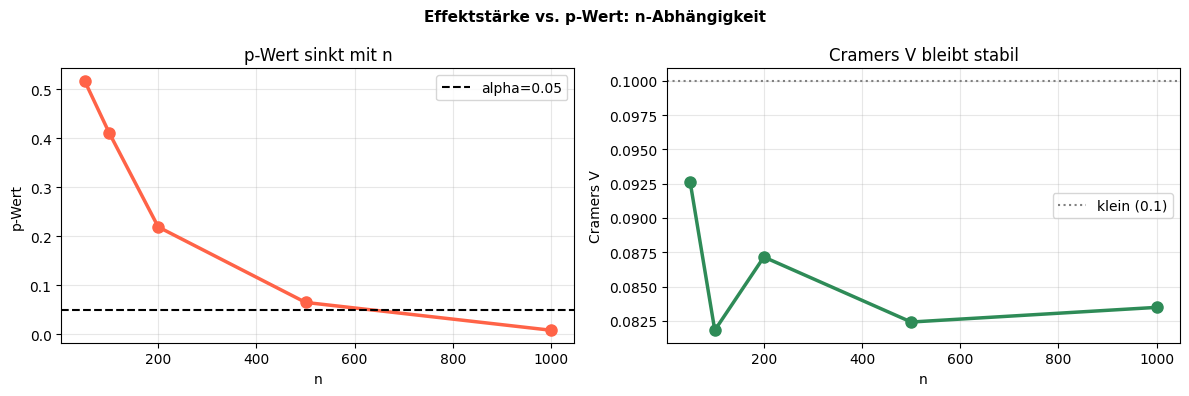

In [31]:
# Cramers V: n-Unabhängigkeit demonstrieren
np.random.seed(42)

def cramers_v(chi2_val, n_val, p_val, q_val):
    return np.sqrt(chi2_val / (n_val * min(p_val-1, q_val-1)))

# Gleicher Effekt, verschiedene n
n_werte_chi = [50, 100, 200, 500, 1000]
ergebnisse_chi = []

for n_c in n_werte_chi:
    # Gleicher wahrer Zusammenhang: Schirmbeispiel-Proportionen * n_c/22
    faktor = n_c / 22
    O_c = np.round(np.array([[5, 7], [5, 5]]) * faktor).astype(int)
    chi2_c, p_c, df_c, erw_c = stats.chi2_contingency(O_c, correction=False)
    cv_c = cramers_v(chi2_c, O_c.sum(), 2, 2)
    ergebnisse_chi.append((n_c, chi2_c, p_c, cv_c))

print("Cramers V vs. p-Wert bei verschiedenem n (gleicher Effekt)")
print(f"{'n':>6}  {'chi2':>8}  {'p-Wert':>10}  {'signif.':>10}  {'Cramers V':>10}")
for n_c, chi2_c, p_c, cv_c in ergebnisse_chi:
    sig = "*" if p_c < 0.05 else "n.s."
    print(f"{n_c:>6}  {chi2_c:>8.3f}  {p_c:>10.4f}  {sig:>10}  {cv_c:>10.4f}")

print()
print("-> Cramers V bleibt konstant (gleicher Effekt), p-Wert sinkt mit n!")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Effektstärke vs. p-Wert: n-Abhängigkeit", fontsize=11, fontweight="bold")

n_l   = [r[0] for r in ergebnisse_chi]
p_l   = [r[2] for r in ergebnisse_chi]
cv_l  = [r[3] for r in ergebnisse_chi]

axes[0].plot(n_l, p_l, "o-", color="tomato",    linewidth=2.5, markersize=8)
axes[0].axhline(0.05, color="black", linestyle="--", linewidth=1.5, label="alpha=0.05")
axes[0].set_title("p-Wert sinkt mit n")
axes[0].set_xlabel("n")
axes[0].set_ylabel("p-Wert")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(n_l, cv_l, "o-", color="seagreen",  linewidth=2.5, markersize=8)
axes[1].axhline(0.1, color="gray", linestyle=":", linewidth=1.5, label="klein (0.1)")
axes[1].set_title("Cramers V bleibt stabil")
axes[1].set_xlabel("n")
axes[1].set_ylabel("Cramers V")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
# Wiederverwendbare chi2-Funktion
def chi2_apa(beob_matrix, var1="Variable 1", var2="Variable 2",
             test_typ="unabhängig", alpha=0.05):
    if test_typ == "unabhängig" or test_typ == "homogenität":
        chi2_r, p_r, df_r, erw_r = stats.chi2_contingency(beob_matrix, correction=False)
        n_r = np.asarray(beob_matrix).sum()
        p_r2, q_r2 = np.asarray(beob_matrix).shape
        cv_r = np.sqrt(chi2_r / (n_r * min(p_r2-1, q_r2-1)))
        erw_label = "Erwartete H. bei Unabhängigkeit"
    else:
        bm = np.asarray(beob_matrix)
        chi2_r, p_r = stats.chisquare(bm[0], f_exp=bm[1])
        df_r = len(bm[0]) - 1
        n_r = bm[0].sum()
        cv_r = np.sqrt(chi2_r / n_r)

    sig_r  = "signifikant" if p_r < alpha else "NICHT signifikant"
    p_str  = "p < .001" if p_r < 0.001 else "p = " + str(round(p_r, 3)).replace("0.", ".")

    print(f"Chi-Quadrat-Test ({test_typ}): {var1} x {var2}")
    print(f"chi2({df_r}) = {chi2_r:.3f}, {p_str}, Cramers V = {cv_r:.3f}")
    print(f"Ergebnis: {sig_r}")
    if p_r < alpha:
        print(f"Es besteht ein signifikanter Zusammenhang zwischen {var1} und {var2}.")
    else:
        print(f"Es besteht kein signifikanter Zusammenhang zwischen {var1} und {var2}.")
    print()

# Alle drei Beispiele
chi2_apa(kt_werte, "Geschlecht", "Schirm", "unabhängig")
print()
chi2_apa(kt_stream, "Dienst", "Altersgruppe", "homogenität")

Chi-Quadrat-Test (unabhängig): Geschlecht x Schirm
chi2(1) = 0.153, p = .696, Cramers V = 0.083
Ergebnis: NICHT signifikant
Es besteht kein signifikanter Zusammenhang zwischen Geschlecht und Schirm.


Chi-Quadrat-Test (homogenität): Dienst x Altersgruppe
chi2(6) = 2.934, p = .817, Cramers V = 0.075
Ergebnis: NICHT signifikant
Es besteht kein signifikanter Zusammenhang zwischen Dienst und Altersgruppe.



## 7. Zusammenfassung

```
Chi-Quadrat-Test – Übersicht
│
├── WANN?
│   Zwei kategorische (nominale/ordinale) Variablen
│   Vergleich beobachteter mit erwarteter Häufigkeit
│
├── DREI VARIANTEN
│   ├── UNABHÄNGIGKEITSTEST
│   │   Gibt es Zusammenhang zw. zwei kategorialen Variablen?
│   │   E_ij = (Zeilensumme_i * Spaltensumme_j) / n
│   │
│   ├── VERTEILUNGSTEST (Anpassungstest)
│   │   Entspricht die Stichprobe einer bekannten Verteilung?
│   │   E_i = n * p_0i  (aus der Grundgesamtheit)
│   │
│   └── HOMOGENITÄTSTEST
│       Kommen mehrere Stichproben aus gleicher Grundgesamtheit?
│       Gleiche Formel wie Unabhängigkeitstest
│
├── FORMEL
│   chi2 = Summe [ (O-E)^2 / E ]
│   df = (p-1)(q-1)  fuer Kreuztabellen
│   df = k-1         fuer Verteilungstest
│
├── VORAUSSETZUNG
│   Alle erwarteten Häufigkeiten E_i > 5
│
├── EFFEKTSTÄRKE CRAMERS V
│   V = sqrt(chi2 / (n * min(p-1, q-1)))
│   < 0.1: vernachlässigbar
│   0.1 - 0.3: klein
│   0.3 - 0.5: mittel
│   > 0.5: gross
│
└── PYTHON
    scipy.stats.chi2_contingency(kreuztabelle)
    scipy.stats.chisquare(beobachtet, f_exp=erwartet)
```

---
Quelle: [numiqo.de/tutorial/chi-quadrat](https://numiqo.de/tutorial/chi-quadrat)